In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


In [2]:
DATA_DIR = "../data"
JOINT_PATH = os.path.join(DATA_DIR, "joint_county_year_2018_2019.csv")

TRAIN_CASTHMA_PATH = os.path.join(DATA_DIR, "train_CASTHMA.csv")
TEST_CASTHMA_PATH = os.path.join(DATA_DIR, "test_CASTHMA.csv")

TRAIN_COPD_PATH = os.path.join(DATA_DIR, "train_COPD.csv")
TEST_COPD_PATH = os.path.join(DATA_DIR, "test_COPD.csv")

# SPLIT_MAPPING_PATH = os.path.join(DATA_DIR, "split_mapping.csv")

RANDOM_STATE = 42

In [3]:
copd_train = pd.read_csv(TRAIN_COPD_PATH)
copd_test = pd.read_csv(TEST_COPD_PATH)
casthma_train = pd.read_csv(TRAIN_CASTHMA_PATH)
casthma_test = pd.read_csv(TEST_CASTHMA_PATH)

In [4]:
copd_train.head()

,index,FIPS,YEAR,pesticide_total_kg,pesticide_anilide_kg,pesticide_carbamate_kg,pesticide_chlorophenoxy_kg,pesticide_organochlorine_kg,pesticide_organophosphate_kg,pesticide_other_kg,...,corn_acres,soybean_acres,cotton_acres,wheat_acres,hay_acres,fruit_veg_acres,rice_acres,sorghum_acres,cat3_CASTHMA,cat3_COPD
0,0,1001,2018,34773.85,3690.60,397.30,6995.35,0.0,2033.75,20854.80,...,2481.5,394.7,11046.3,42.7,35341.6,27.1,0.0,220.8,medium,medium
1,1,1001,2019,21120.00,2582.55,9.70,5230.55,0.0,763.95,11639.25,...,2481.5,394.7,11046.3,42.7,35341.6,27.1,0.0,220.8,medium,medium
2,2,1003,2018,277331.10,61192.90,1327.20,10561.50,0.0,4287.00,185663.25,...,13716.7,12477.7,23302.1,539.3,9794.7,1032.7,0.0,377.4,medium,medium
3,3,1003,2019,125643.65,30532.30,24.45,4197.00,0.0,7219.45,75275.55,...,13716.7,12477.7,23302.1,539.3,9794.7,1032.7,0.0,377.4,low,medium
4,6,1007,2018,11299.05,1073.55,0.00,5137.15,0.0,249.05,3777.65,...,711.4,288.9,336.3,3.8,7087.7,0.4,0.0,0.7,high,high


# Asthma

In [10]:
features = casthma_train.columns[1:-2]

In [83]:
features2 = features.drop(['NAME','COPD', 'CASTHMA']) #Drop string

In [76]:
casthma_train.isna().sum().to_numpy().nonzero() #check

(array([456, 457, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474,
        475, 476, 477]),)

In [77]:
casthma_train.isna().sum().iloc[casthma_train.isna().sum().to_numpy().nonzero()].index

Index(['nchs_urban_rural', 'cropland_diversity', 'ipm_breadth_acre',
       'chemical_reliance_acre', 'ipm_breadth_acre_rescaled',
       'chemical_reliance_acre_rescaled', 'ipm_breadth_value',
       'chemical_reliance_value', 'ipm_doc_coverage_share',
       'mean_text_quality', 'mean_geo_confidence', 'weighted_doc_age',
       'county_crop_concentration', 'specialty_crop_share', 'total_ag_value',
       'ipm_primary_match_tier'],
      dtype='str')

In [84]:
features3 =features2.drop(casthma_train.isnull().sum().iloc[casthma_train.isnull().sum().to_numpy().nonzero()].index)

In [102]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import StratifiedGroupKFold

In [24]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups

rmse_logreg = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.cat3_CASTHMA.astype('category').cat.codes
    x_tt = casthma_tt[features3]

    x_val = casthma_val[features3]
    y_val = casthma_val.cat3_CASTHMA.astype('category').cat.codes

    model1 = LogisticRegression(max_iter=1000)
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_logreg.append(rmse(y_val, pred1))


c:\Users\Xaalthe71\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Xaalthe71\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

In [25]:
rmse_logreg

[0.9742160336041298,
 0.9830250553478826,
 0.9892780407133133,
 0.9707905080532647]

In [103]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups

rmse_xgb = []
acc_xgb = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.cat3_CASTHMA.astype('category').cat.codes
    x_tt = casthma_tt[features3]

    x_val = casthma_val[features3]
    y_val = casthma_val.cat3_CASTHMA.astype('category').cat.codes

    model1 = XGBClassifier(objective='multi:softmax')
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_xgb.append(rmse(y_val, pred1))
    acc_xgb.append(accuracy_score(y_val, pred1))


In [81]:
rmse_xgb

[0.6989318615762461, 0.7444375004781977, 0.742476621884015, 0.7237739178849473]

In [104]:
acc_xgb

[0.8070607553366174, 0.7857142857142857, 0.7760459392945037, 0.796875]

In [107]:
y_tt = casthma_train.cat3_CASTHMA.astype('category').cat.codes
x_tt = casthma_train[features3]
x_test = casthma_test[features3]
y_test =  casthma_test.cat3_CASTHMA.astype('category').cat.codes

model_xgb = XGBClassifier(objective='multi:softmax')
model_xgb.fit(x_tt, y_tt)

pred_xgb = model_xgb.predict(x_test)
rmse(y_test, pred_xgb)

0.7009794767232359

In [109]:
print(accuracy_score(y_test, pred_xgb))

0.8118323746918652


In [88]:
model_xgb.feature_importances_.argsort()

array([ 17,  19,  22,  26,  28,  30, 438, 439, 444, 440, 441, 442, 424,
       422, 425, 427, 402, 429,  32,  33,  36,  34,  38,  41, 411,  43,
        46,  47, 412, 404, 415, 414,  79,  65,  48,  49,  50,  53,  56,
        59, 393, 384, 385, 391, 396, 394, 397,  64, 378, 373,  67,  71,
        72,  74,  75,  76, 382, 380, 376, 377, 352, 361, 356, 355, 301,
       314, 315, 364,  81,  84,  87,  88, 338,  91, 336, 337, 342, 340,
       343, 346, 323, 350,  96,  97, 103, 104, 105, 107, 335, 325, 328,
       333, 306, 304, 308, 311, 275, 128, 131, 317, 318, 112, 115, 117,
       124, 126, 127, 290, 293, 296, 297, 298, 282, 277, 279, 134, 137,
       138, 140, 142, 285, 284, 280, 269, 268, 266, 259, 258, 200, 218,
       220, 221, 222, 151, 152, 153, 154, 157, 158, 242, 245, 250, 252,
       253, 225, 162, 163, 164, 167, 170, 174, 224, 235, 226, 231, 234,
       239, 238, 211, 216,  12,   6, 182, 183, 185, 223, 176, 178, 179,
       180, 194, 197, 191, 256,  82, 243,  58,  27, 428, 351, 20

In [98]:
model_xgb.feature_importances_[371]

np.float32(0.042377863)

In [90]:
casthma_test.columns[[371, 257, 15, 430, 454, 390, 366, 160]]

Index(['pesticide_quinoxyfen_kg', 'pesticide_kaolin_clay_kg',
       'pesticide_2_4_db_kg', 'pesticide_triadimefon_kg', 'pct_asian',
       'pesticide_spiromesifen_kg', 'pesticide_pyriproxyfen_kg',
       'pesticide_diuron_kg'],
      dtype='str')

In [44]:
x_val = casthma_test[features3]
y_val = casthma_test.cat3_CASTHMA.astype('category').cat.codes

rmse(y_val, model_xgb.predict(x_val))

0.0

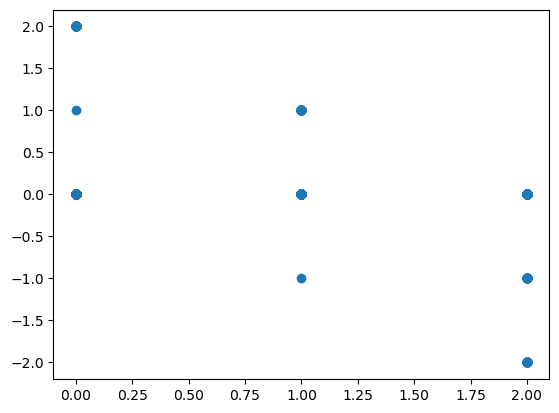

In [111]:
plt.scatter(y_test, pred_xgb-y_test)

In [ ]:
y_val = casthma_val.cat3_CASTHMA.astype('category').cat.codes

In [85]:
y_val

8       2
9       2
10      0
11      0
12      0
       ..
4836    1
4859    1
4860    1
4861    1
4862    1
Length: 1216, dtype: int8

In [28]:
rmse_rf = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.cat3_CASTHMA.astype('category').cat.codes
    x_tt = casthma_tt[features3]

    x_val = casthma_val[features3]
    y_val = casthma_val.cat3_CASTHMA.astype('category').cat.codes

    model1 = RandomForestClassifier()
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_rf.append(rmse(y_val, pred1))

In [29]:
rmse_rf

[0.3669427233686058, 0.3669427233686058, 0.3352420060569715, 0.414578098794425]

In [38]:
from sklearn.metrics import roc_auc_score

In [101]:
y_tt = casthma_train.cat3_CASTHMA.astype('category').cat.codes
x_tt = casthma_train[features3]

model_rf =RandomForestClassifier()
model_rf.fit(x_tt, y_tt)

pred_rf = model_rf.predict(x_tt)
rmse(y_tt, pred_rf)

0.0

In [59]:
model_rf.feature_importances_.argsort()

array([ 17,  26,  28,  30, 441, 440,  32, 442,  47,  34,  46, 404, 402,
        49, 427, 422,  67,  71,  72,  75,  76,  79, 385, 391,  88, 393,
        81,  84, 415, 414, 412, 411, 124, 377, 378, 104, 396, 397, 134,
       380, 140, 137, 355, 142, 376, 373, 382, 304, 328, 179, 178, 162,
       174, 170, 164, 163, 350, 337, 343, 342, 153, 154, 157, 151, 318,
       221, 220, 218, 296, 223, 226, 224, 235, 238, 279, 185, 308, 317,
       200, 282, 266, 269,   6, 275, 234, 253, 250, 352, 103, 180, 258,
        64, 314, 191,  74,  19, 293, 127, 439,  53, 107, 280, 338, 126,
       364, 252, 340, 242,  38, 429, 216, 231,  96,  91,  48, 112, 311,
       158, 424, 298, 113, 284, 245,  12, 117, 105, 416,  22, 285, 183,
       438, 182, 131, 297,  43, 111, 301, 323,  36, 211, 335,  87, 361,
       152, 306, 139, 428,  58, 177, 167,  59, 425, 444, 128, 290, 325,
       333, 222,  99,  51, 356, 101, 254, 189,  50, 334, 384, 336, 239,
       346, 161, 268,  41, 320, 315, 138,  40, 256, 199, 194,  6

In [60]:
model_rf.feature_importances_[454]

np.float64(0.2611333680474796)

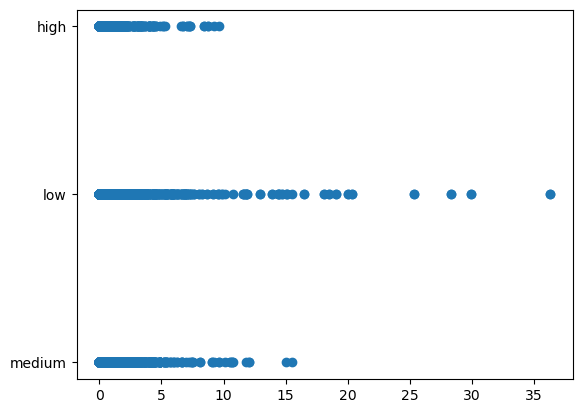

In [62]:
plt.scatter(casthma_train['pct_asian'], casthma_train['cat3_CASTHMA'])

In [99]:
y_tt = casthma_train.cat3_CASTHMA.astype('category').cat.codes
x_tt = casthma_train['pct_asian']

model_xgb = XGBClassifier(objective='multi:softprob')
model_xgb.fit(x_tt, y_tt)

pred_xgb = model_xgb.predict(x_tt)
r2_score(y_tt, pred_xgb)

-0.5129805325346031

In [100]:
y_tt = casthma_train.cat3_CASTHMA.astype('category').cat.codes
x_tt = casthma_train['pct_asian']

model_xgb = XGBClassifier(objective='multi:softprob')
model_xgb.fit(x_tt, y_tt)

pred_xgb = model_xgb.predict(x_tt)
rmse(y_tt, pred_xgb)

1.002153296520525

XGBoost was the best so we will try to optimize XGBoost

In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [113]:
param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": np.arange(100,800,100),
              "learning_rate": [0.01, 0.1, 1]}

In [114]:
y_tt = casthma_train.cat3_CASTHMA.astype('category').cat.codes
x_tt = casthma_train[features3]
model_xgb1 = XGBClassifier()
search = GridSearchCV(model_xgb1, param_grid=param_grid, cv=4, scoring='accuracy').fit(x_tt, y_tt)

In [115]:
search.best_params_

{'learning_rate': 1, 'max_depth': 4, 'n_estimators': np.int64(200)}

In [123]:
search.best_score_

np.float64(0.6126061353053958)

In [117]:
xgbmodelpipe = Pipeline([('scaler',StandardScaler()), ('xgb',XGBClassifier(**search.best_params_))])

In [118]:
xgbmodelpipe.fit(x_tt, y_tt)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


In [121]:
accuracy_score(y_tt, xgbmodelpipe.predict(x_tt))

1.0

In [122]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=casthma_train.cat3_CASTHMA # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=casthma_train[['FIPS','CASTHMA']] # don't need full data for this one
groups=casthma_train.FIPS # using county index as groups

rmse_xgb = []
acc_xgb = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    casthma_val = casthma_train.iloc[val_index,:]
    casthma_tt = casthma_train.iloc[train_index,:]


    y_tt = casthma_tt.cat3_CASTHMA.astype('category').cat.codes
    x_tt = casthma_tt[features3]

    x_val = casthma_val[features3]
    y_val = casthma_val.cat3_CASTHMA.astype('category').cat.codes

    model1 = XGBClassifier(**search.best_params_)
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_xgb.append(rmse(y_val, pred1))
    acc_xgb.append(accuracy_score(y_val, pred1))

In [124]:
print(rmse_xgb)
print(acc_xgb)

[0.705944731459344, 0.7521179727887041, 0.7245829894591908, 0.75]
[0.8021346469622331, 0.7889983579638752, 0.7899917965545529, 0.787828947368421]


In [125]:
# first, splitting between training+validation (80%) and test (20%)
sgkf = StratifiedGroupKFold(n_splits=4,random_state = RANDOM_STATE, shuffle=True) # shuffle so that we randomly assign counties to test
y=copd_train.cat3_COPD # the class we want to stratify on - in this case the categorical labels for CASTHMA
X=copd_train[['FIPS','COPD']] # don't need full data for this one
groups=copd_train.FIPS # using county index as groups

rmse_xgb_copd = []
acc_xgb_copd = []
# we're looping but will grab only the first fold and save out the test data
for i, (train_index, val_index) in enumerate(sgkf.split(X, y, groups)):
    copd_val = copd_train.iloc[val_index,:]
    copd_tt = copd_train.iloc[train_index,:]


    y_tt = copd_tt.cat3_COPD.astype('category').cat.codes
    x_tt = copd_tt[features3]

    x_val = copd_val[features3]
    y_val = copd_val.cat3_COPD.astype('category').cat.codes

    model1 = XGBClassifier(**search.best_params_)
    model1.fit(x_tt, y_tt)

    pred1 = model1.predict(x_val)
    rmse_xgb_copd.append(rmse(y_val, pred1))
    acc_xgb_copd.append(accuracy_score(y_val, pred1))

In [126]:
print(rmse_xgb_copd)
print(acc_xgb_copd)

[0.6894704186026249, 0.6909438841970346, 0.6664613805442733, 0.6900655593423543]
[0.8054187192118226, 0.8060805258833197, 0.8218390804597702, 0.8070607553366174]


In [128]:
model1.feature_importances_.argsort()

array([333,  47,  48,  49,  50,  53, 298, 299, 301, 304, 323, 325, 326,
       327, 328,   6,  46, 438, 439, 440, 441, 442, 444, 446,  34, 306,
       308, 311, 314, 315, 317, 318, 334, 335, 336, 337,  58,  59,  63,
        64,  65, 418, 421, 422, 424, 425,  44, 427, 428, 429, 430, 432,
        67,  68,  71,  72,  74,  75,  76,  78,  79,  81,  84,  87,  88,
        91,  96, 402, 404, 409, 411, 412, 414, 415, 416,  99, 100, 103,
       104, 105, 106, 107, 110, 111, 112, 113, 115, 117, 121, 124, 125,
       126, 127, 128, 129, 388, 389, 390, 391, 392, 393, 394, 396, 397,
       398, 401, 131, 134, 137, 138, 139, 140, 142, 144, 151, 152, 153,
       154, 157, 279, 280, 282, 284, 285, 286, 290, 293, 294, 296, 297,
       158, 161, 370, 371, 372, 373, 374, 376, 377, 378, 380, 382, 384,
       385, 162, 163, 164, 165, 167, 170, 172, 174, 176, 177, 178, 179,
       180, 182, 183, 185, 186, 187, 189, 190, 191, 194, 200, 202, 208,
       209, 355, 356, 359, 361, 362, 364, 365, 352, 258, 259, 26

In [129]:
casthma_test.columns[[369, 119, 249, 454, 407, 1, 102]]

Index(['pesticide_pyroxsulam_kg', 'pesticide_cyhalothrin_gamma_kg',
       'pesticide_indoxacarb_kg', 'pct_asian', 'pesticide_tebuthiuron_kg',
       'FIPS', 'pesticide_copper_oxychloride_s_kg'],
      dtype='str')